---
title: "Kronecker GP + GEV likelihood"
---

# Annual temperature extremes over Spain — an additive space + time GP with GEV observations

This notebook threads together three modelling ingredients, now built on the
`xtremax` + `pyrox` + `gaussx` stack rather than hand-rolled helpers:

1. **Latent space + time GPs** via [`pyrox.gp`](https://github.com/jejjohnson/pyrox)
   — a spatial GP $\mu(s)$ over stations and a temporal residual GP $\tau_r(t)$
   over GMST, each drawn with a whitened `gp_sample` inside a NumPyro model.
2. **A Generalized Extreme Value likelihood** for yearly maxima — supplied by
   [`xtremax`](https://github.com/jejjohnson/xtremax)
   (`GeneralizedExtremeValueDistribution`), so we no longer carry a bespoke
   `numpyro.distributions.Distribution` subclass.
3. **Variational inference** with a NumPyro `AutoNormal` guide and an `optax`
   optimiser — the mean-field posterior is learned by SVI, replacing the
   hand-written `VariationalFactor` / closed-form-KL / Gauss–Hermite-ELL loop.

The pedagogical payoff is unchanged: **return-level maps** — the temperature
exceeded once every 25 or 100 years — at current and warming-projected
climates, computed with `xtremax.gev_return_level`.

## Background

### Block maxima and the GEV distribution

Let $X_1, \dots, X_n$ be i.i.d. draws from some well-behaved base distribution
and set $M_n = \max_i X_i$. The Fisher–Tippett–Gnedenko theorem says the only
non-degenerate limits of normalised $M_n$ are **Generalized Extreme Value**
laws,

$$\mathrm{GEV}(y \mid \mu, \sigma, \xi) = \frac{1}{\sigma}\,\bigl[1 + \xi\,z\bigr]_+^{-(1 + 1/\xi)}\,\exp\!\Bigl(-\bigl[1 + \xi z\bigr]_+^{-1/\xi}\Bigr), \qquad z = \frac{y - \mu}{\sigma},$$

with $\xi > 0$ Fréchet (heavy tail), $\xi = 0$ Gumbel, $\xi < 0$ Weibull
(bounded above). Mediterranean max-temperature data typically gives
$\xi \in [0.05, 0.25]$. `xtremax` ships this distribution and its quantile /
return-level functions, matching `scipy.stats.genextreme` (with `c = -\xi`) to
machine precision — we verify that below.

### Additive separable structure

We treat space and time as two independent zero-mean GPs with **no
interaction**, $f(s, t) = \mu_0 + \mu(s) + \tau(t)$, and split the temporal
part into a linear warming response plus a smooth residual,

$$\tau(t) = \beta\,\bigl(\mathrm{GMST}(t) - \overline{\mathrm{GMST}}\bigr) + \tau_r(t), \qquad \tau_r \sim \mathcal{GP}(0, k_t).$$

Fixing the *level* on $\mu_0$ and the *trend* on $\beta$ — by centering the two
GP fields to be zero-mean — removes the additive identifiability ($\mu_0$ vs
the mean of $\mu(s)$; $\beta$ vs the mean of $\tau_r$) that otherwise lets the
latent fields silently absorb the constant and the slope.

## Setup

In [1]:
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Predictive, Trace_ELBO, autoguide
from numpyro.infer.initialization import init_to_value
from jaxtyping import Array, Float
from scipy.stats import genextreme

# pyrox provides the GP prior + whitened latent sampling and the kernel maths;
# xtremax provides the GEV distribution and return-level helpers.
from pyrox.gp import GPPrior, Matern, RBF, gp_sample
from pyrox.gp._src.kernels import matern_kernel, rbf_kernel
from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_return_level

jax.config.update("jax_enable_x64", True)

/home/user/research_notebook/projects/gaussian_processes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic data — a warming Spain

### Stations

Forty stations scattered across the Iberian Peninsula's bounding box, rejecting
obvious ocean points with a crude mask. In a real study you'd load AEMET or
ERA5 yearly maxima — the inference below is unchanged.

In [2]:
SPAIN_BBOX = (-9.5, 3.5, 36.0, 43.8)  # lon_min, lon_max, lat_min, lat_max


def _on_land(lon: Float[Array, " N"], lat: Float[Array, " N"]) -> Float[Array, " N"]:
    west_of_galicia = (lon < -8.8) & (lat > 42.3)
    below_africa = lat < 36.2
    east_mediterranean = (lon > 2.5) & (lat < 39.0)
    return ~(west_of_galicia | below_africa | east_mediterranean)


def _sample_stations(key: jr.PRNGKey, n_target: int) -> Float[Array, "n 2"]:
    candidates = jr.uniform(
        key,
        (n_target * 4, 2),
        minval=jnp.array([SPAIN_BBOX[0], SPAIN_BBOX[2]]),
        maxval=jnp.array([SPAIN_BBOX[1], SPAIN_BBOX[3]]),
    )
    return candidates[_on_land(candidates[:, 0], candidates[:, 1])][:n_target]


S = 40  # number of stations
T = 40  # number of years
YEAR_0 = 1985
YEARS = jnp.arange(YEAR_0, YEAR_0 + T)

key = jr.PRNGKey(2024)
key, key_stations = jr.split(key)
stations = _sample_stations(key_stations, S)
lon_st = stations[:, 0]
lat_st = stations[:, 1]

### GMST proxy

Global mean surface temperature rises roughly linearly over 1985–2024. We use
a linear trend plus AR(1) red noise so the series has climate-like texture but
a monotone trend. The GMST *anomaly* (relative to 1985) feeds the temporal GP.

In [3]:
def synthetic_gmst(years: Float[Array, " T"], key: jr.PRNGKey) -> Float[Array, " T"]:
    t_norm = (years - years[0]) / jnp.maximum(years[-1] - years[0], 1)
    trend = 0.1 + 0.8 * t_norm
    white = 0.05 * jr.normal(key, (years.shape[0],))

    def step(prev, eps):
        cur = 0.6 * prev + eps
        return cur, cur

    _, red = jax.lax.scan(step, white[0], white[1:])
    return trend + jnp.concatenate([white[:1], red])


key, key_gmst = jr.split(key)
gmst = synthetic_gmst(YEARS, key_gmst)
gmst_c = gmst - jnp.mean(gmst)
print(f"GMST: start {float(gmst[0]):.2f} °C  →  end {float(gmst[-1]):.2f} °C")

GMST: start 0.02 °C  →  end 0.85 °C


### Ground-truth field

A single ground-truth realisation of the additive model from fixed kernels.
The covariance matrices are built directly with `pyrox`'s pure kernel
functions `matern_kernel` / `rbf_kernel` — no bespoke gram wrappers.

In [4]:
def draw_from_gp(K: Float[Array, "N N"], key: jr.PRNGKey, jitter: float = 1e-4) -> Float[Array, " N"]:
    L = jnp.linalg.cholesky(K + jitter * jnp.eye(K.shape[0]))
    return L @ jr.normal(key, (K.shape[0],))


TRUTH = {
    "mu0": 35.0,
    "k_s_var": 4.0,
    "k_s_ls": 2.0,
    "k_t_var": 0.02,
    "k_t_ls": 0.25,
    "beta_gmst": 1.5,  # °C extremes per °C GMST anomaly
    "gev_sigma": 1.8,
    "gev_xi": 0.12,  # Fréchet regime
}

K_s_truth = matern_kernel(stations, stations, jnp.asarray(TRUTH["k_s_var"]), jnp.asarray(TRUTH["k_s_ls"]), nu=1.5)
K_t_truth = rbf_kernel(gmst[:, None], gmst[:, None], jnp.asarray(TRUTH["k_t_var"]), jnp.asarray(TRUTH["k_t_ls"]))

key, key_mu, key_tau = jr.split(key, 3)
mu_truth = draw_from_gp(K_s_truth, key_mu)  # (S,) — roughly zero-mean spatial offset
tau_truth = TRUTH["beta_gmst"] * gmst_c + draw_from_gp(K_t_truth, key_tau)  # (T,)
f_truth = TRUTH["mu0"] + mu_truth[:, None] + tau_truth[None, :]  # (S, T)

### GEV observation model — from `xtremax`

We use `xtremax.GeneralizedExtremeValueDistribution` directly (Coles
parameterisation, $1 + \xi z$). Verify it matches `scipy.stats.genextreme`
with `c = -\xi` across the Fréchet, Gumbel, and Weibull regimes.

In [5]:
y_grid = jnp.linspace(-2.0, 25.0, 60)
loc_, scale_ = 3.0, 1.5
for xi_test in [0.2, 0.0, -0.2]:
    ours = GEV(loc=loc_, scale=scale_, concentration=xi_test).log_prob(y_grid)
    theirs = genextreme.logpdf(np.asarray(y_grid), c=-xi_test, loc=loc_, scale=scale_)
    mask = np.isfinite(theirs)
    diff = float(jnp.max(jnp.abs(ours[mask] - theirs[mask])))
    print(f"xtremax GEV vs scipy  (ξ={xi_test:+.1f}):  max|Δ| = {diff:.2e}")

xtremax GEV vs scipy  (ξ=+0.2):  max|Δ| = 5.12e-13
xtremax GEV vs scipy  (ξ=+0.0):  max|Δ| = 1.42e-14


xtremax GEV vs scipy  (ξ=-0.2):  max|Δ| = 5.33e-15


### Draw the observations

In [6]:
key, key_obs = jr.split(key)
y_obs = GEV(loc=f_truth, scale=TRUTH["gev_sigma"], concentration=TRUTH["gev_xi"]).sample(key_obs)
Y_MEAN = float(jnp.mean(y_obs))  # module-level constant for the mu0 prior
print(f"observations shape: {y_obs.shape}  range: [{float(y_obs.min()):.1f}, {float(y_obs.max()):.1f}] °C")

observations shape: (40, 40)  range: [28.2, 57.4] °C


### Data inspection — stations + a few timeseries

/home/user/research_notebook/projects/gaussian_processes/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


/home/user/research_notebook/projects/gaussian_processes/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


/home/user/research_notebook/projects/gaussian_processes/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


/home/user/research_notebook/projects/gaussian_processes/.venv/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


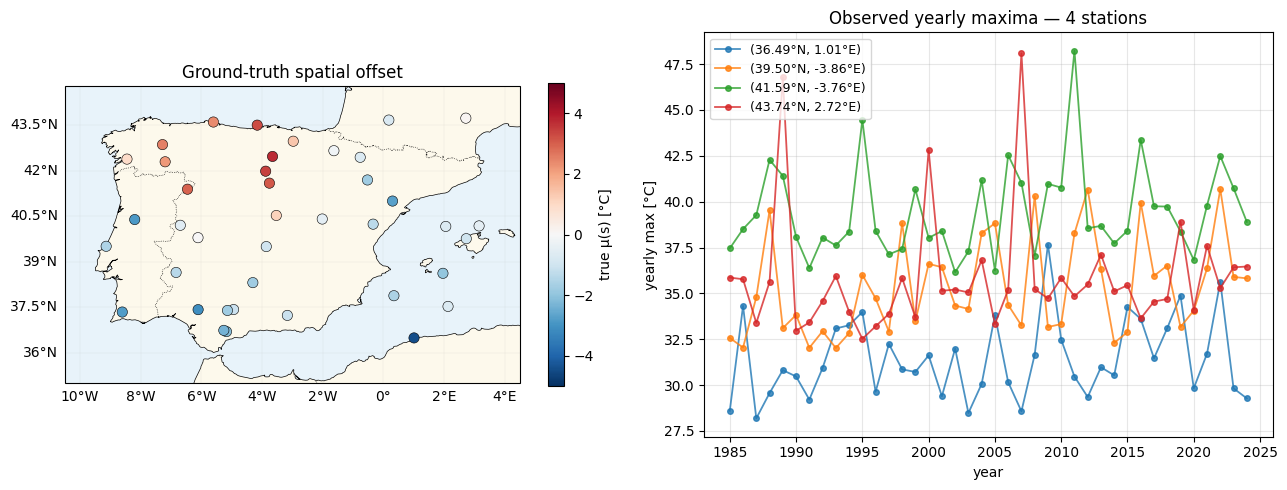

In [7]:
def plot_stations(ax, values: Float[Array, " S"], *, cmap: str, vlim: tuple, label: str) -> None:
    ax.set_extent([SPAIN_BBOX[0] - 1, SPAIN_BBOX[1] + 1, SPAIN_BBOX[2] - 1, SPAIN_BBOX[3] + 1], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="#e8f3fa")
    ax.add_feature(cfeature.LAND, facecolor="#fdf9ec")
    sc = ax.scatter(
        np.asarray(lon_st), np.asarray(lat_st), c=np.asarray(values), cmap=cmap,
        vmin=vlim[0], vmax=vlim[1], s=55, edgecolors="k", linewidths=0.4,
        transform=ccrs.PlateCarree(), zorder=5,
    )
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.4)
    gl.top_labels = gl.right_labels = False
    plt.colorbar(sc, ax=ax, shrink=0.75, label=label)


fig = plt.figure(figsize=(13, 5))
ax_map = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
plot_stations(ax_map, mu_truth, cmap="RdBu_r", vlim=(-5, 5), label="true μ(s) [°C]")
ax_map.set_title("Ground-truth spatial offset")

order_by_lat = jnp.argsort(lat_st)
picks = jnp.array([order_by_lat[i] for i in (0, S // 3, 2 * S // 3, S - 1)])
ax_ts = fig.add_subplot(1, 2, 2)
for s in picks:
    s_int = int(s)
    ax_ts.plot(YEARS, y_obs[s_int, :], "o-", lw=1.3, ms=4, alpha=0.8,
               label=f"({float(lat_st[s_int]):.2f}°N, {float(lon_st[s_int]):.2f}°E)")
ax_ts.set_xlabel("year")
ax_ts.set_ylabel("yearly max [°C]")
ax_ts.set_title("Observed yearly maxima — 4 stations")
ax_ts.legend(loc="upper left", fontsize=9)
ax_ts.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## The model — pyrox GP latents + xtremax GEV likelihood

A single NumPyro model:

- `Matern`-3/2 spatial kernel and `RBF` temporal kernel from `pyrox.gp`, each
  with log-normal hyperpriors;
- latent fields drawn with whitened `gp_sample` (well-conditioned reparam),
  then **centered** so $\mu_0$ owns the level and $\beta$ owns the trend;
- an `xtremax` GEV likelihood on the $S \times T$ grid of yearly maxima.

In [8]:
def model(stations, gmst, y=None):
    gmst_c = gmst - jnp.mean(gmst)

    k_s = Matern(nu=1.5)
    k_s.set_prior("variance", dist.LogNormal(jnp.log(2.0), 0.5))
    k_s.set_prior("lengthscale", dist.LogNormal(jnp.log(2.0), 0.5))
    k_t = RBF()
    k_t.set_prior("variance", dist.LogNormal(jnp.log(0.05), 0.5))
    k_t.set_prior("lengthscale", dist.LogNormal(jnp.log(0.5), 0.5))

    mu_s = gp_sample("mu_s", GPPrior(kernel=k_s, X=stations), whitened=True)
    tau_r = gp_sample("tau_r", GPPrior(kernel=k_t, X=gmst[:, None]), whitened=True)
    # Center to remove the additive degeneracies (level → mu0, trend → beta).
    mu_s = mu_s - jnp.mean(mu_s)
    tau_r = tau_r - jnp.mean(tau_r)

    mu0 = numpyro.sample("mu0", dist.Normal(Y_MEAN, 5.0))
    beta = numpyro.sample("beta", dist.Normal(1.0, 1.0))
    log_sigma = numpyro.sample("log_sigma", dist.Normal(jnp.log(2.0), 0.4))
    xi = numpyro.sample("xi", dist.Normal(0.1, 0.1))
    sigma = jnp.exp(log_sigma)

    tau_total = beta * gmst_c + tau_r  # full temporal effect
    loc = mu0 + mu_s[:, None] + tau_total[None, :]

    numpyro.deterministic("mu_field", mu_s)        # centered spatial offset
    numpyro.deterministic("tau_total", tau_total)  # trend + residual
    numpyro.deterministic("sigma", sigma)
    numpyro.sample("y", GEV(loc=loc, scale=sigma, concentration=xi), obs=y)

## Inference — SVI with a NumPyro `AutoNormal` guide

`optax.zero_nans()` guards against the occasional out-of-support GEV draw
(a `-inf` log-prob → NaN gradient) during early exploration; `init_to_value`
starts the location near the data so we don't begin deep out of support.

In [9]:
guide = autoguide.AutoNormal(
    model,
    init_loc_fn=init_to_value(
        values={"mu0": Y_MEAN, "beta": 1.0, "log_sigma": float(jnp.log(2.0)), "xi": 0.1}
    ),
)
optimizer = numpyro.optim.optax_to_numpyro(
    optax.chain(optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(3e-3))
)
svi = SVI(model, guide, optimizer, Trace_ELBO())

t0 = time.time()
svi_result = svi.run(jr.PRNGKey(0), 5000, stations, gmst, y_obs, progress_bar=False)
losses = np.asarray(svi_result.losses)
print(f"SVI finished in {time.time() - t0:.1f}s")

# Posterior draws: deterministics via Predictive, scalar latents via the guide.
post = Predictive(model, guide=guide, params=svi_result.params, num_samples=600)(
    jr.PRNGKey(3), stations, gmst
)
lat = guide.sample_posterior(jr.PRNGKey(4), svi_result.params, sample_shape=(600,))

print(f"fitted μ₀  = {float(lat['mu0'].mean()):.2f} ± {float(lat['mu0'].std()):.2f}  (truth {TRUTH['mu0']})")
print(f"fitted β   = {float(lat['beta'].mean()):.2f} ± {float(lat['beta'].std()):.2f}  (truth {TRUTH['beta_gmst']})")
print(f"fitted σ   = {float(post['sigma'].mean()):.2f} ± {float(post['sigma'].std()):.2f}  (truth {TRUTH['gev_sigma']})")
print(f"fitted ξ   = {float(lat['xi'].mean()):.3f} ± {float(lat['xi'].std()):.3f}  (truth {TRUTH['gev_xi']})")

SVI finished in 14.1s


fitted μ₀  = 34.51 ± 0.05  (truth 35.0)
fitted β   = 1.20 ± 0.19  (truth 1.5)
fitted σ   = 1.77 ± 0.04  (truth 1.8)
fitted ξ   = 0.129 ± 0.021  (truth 0.12)


### Loss curve

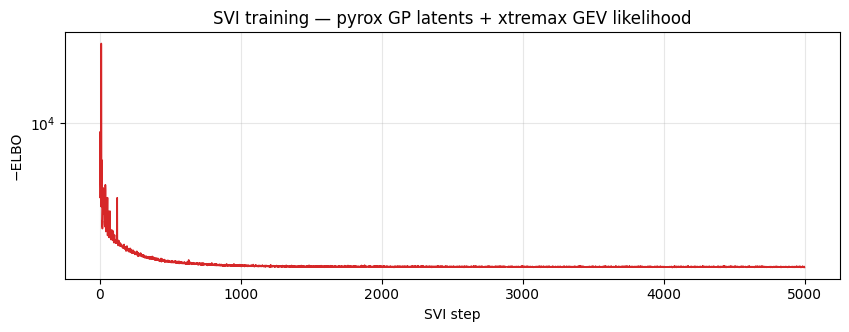

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.2))
finite = np.isfinite(losses)
ax.plot(np.arange(len(losses))[finite], losses[finite], "C3-", lw=1.2)
ax.set_xlabel("SVI step")
ax.set_ylabel("−ELBO")
ax.set_yscale("symlog", linthresh=100.0)
ax.set_title("SVI training — pyrox GP latents + xtremax GEV likelihood")
ax.grid(alpha=0.3, which="both")
plt.show()

## Parameter recovery

The additive model has a residual constant degeneracy between $\mu_0$ and the
mean of $\mu(s)$; with the centered fields the posterior tracks the truth's
*shape* with a small (≲ 0.5 °C) vertical offset.

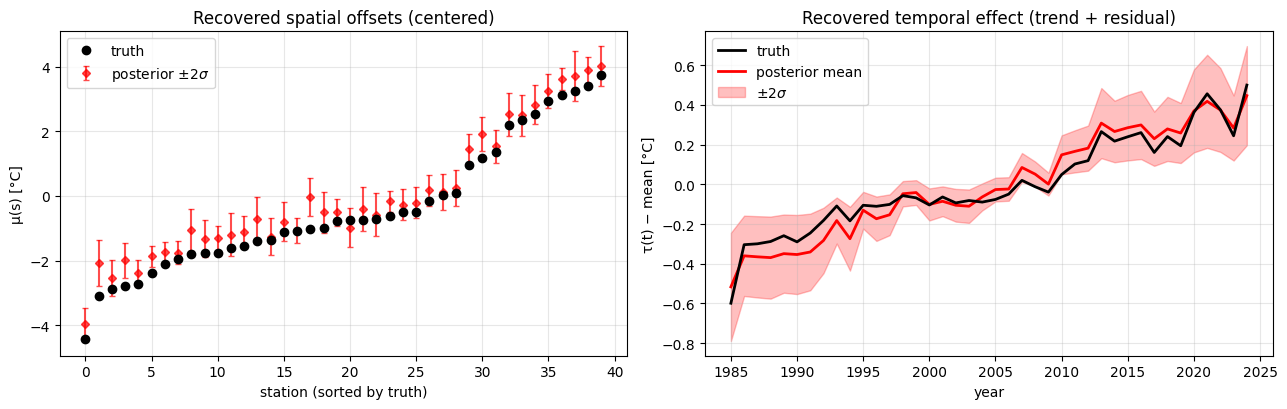

In [11]:
m_s_fit = post["mu_field"].mean(0)
v_s_fit = post["mu_field"].std(0)
tau_fit = post["tau_total"].mean(0)
tau_sd = post["tau_total"].std(0)
tau_truth_c = tau_truth - jnp.mean(tau_truth)  # compare zero-mean temporal effects

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
order_s = jnp.argsort(mu_truth)
x = jnp.arange(S)
ax.plot(x, mu_truth[order_s], "ko", ms=6, label="truth", zorder=3)
ax.errorbar(x, m_s_fit[np.asarray(order_s)], yerr=2 * v_s_fit[np.asarray(order_s)],
            fmt="rD", ms=4, alpha=0.7, label=r"posterior $\pm 2\sigma$", capsize=2)
ax.set_xlabel("station (sorted by truth)")
ax.set_ylabel("μ(s) [°C]")
ax.set_title("Recovered spatial offsets (centered)")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(YEARS, tau_truth_c, "k-", lw=2, label="truth", zorder=3)
ax.plot(YEARS, tau_fit, "r-", lw=2, label="posterior mean")
ax.fill_between(YEARS, tau_fit - 2 * tau_sd, tau_fit + 2 * tau_sd, alpha=0.25, color="red", label=r"$\pm 2\sigma$")
ax.set_xlabel("year")
ax.set_ylabel("τ(t) − mean [°C]")
ax.set_title("Recovered temporal effect (trend + residual)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### GEV tail recovery

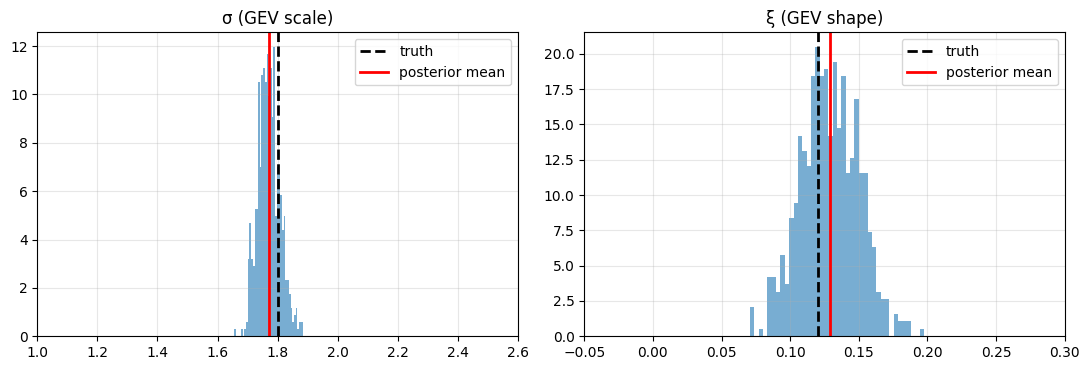

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (name, truth_val, draws, xr) in zip(
    axes,
    [("σ (GEV scale)", TRUTH["gev_sigma"], post["sigma"], (1.0, 2.6)),
     ("ξ (GEV shape)", TRUTH["gev_xi"], lat["xi"], (-0.05, 0.3))],
    strict=True,
):
    ax.hist(np.asarray(draws).ravel(), bins=40, color="C0", alpha=0.6, density=True)
    ax.axvline(truth_val, color="k", ls="--", lw=2, label="truth")
    ax.axvline(float(np.mean(draws)), color="red", lw=2, label="posterior mean")
    ax.set_xlim(*xr)
    ax.set_title(name)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## The payoff — return-level maps

The $T_r$-year return level is $z_p = F^{-1}(1 - 1/T_r)$, computed with
`xtremax.gev_return_level`. We map 25- and 100-year return temperatures for a
typical year at the **end of record (2024)** and a **warming projection
(2050)** obtained by linearly extrapolating GMST.

GMST 2024 = 0.848 °C, GMST 2050 (extrapolated) = 1.398 °C


2024 → 2050 mean shift in 100-yr return level: 0.66 °C


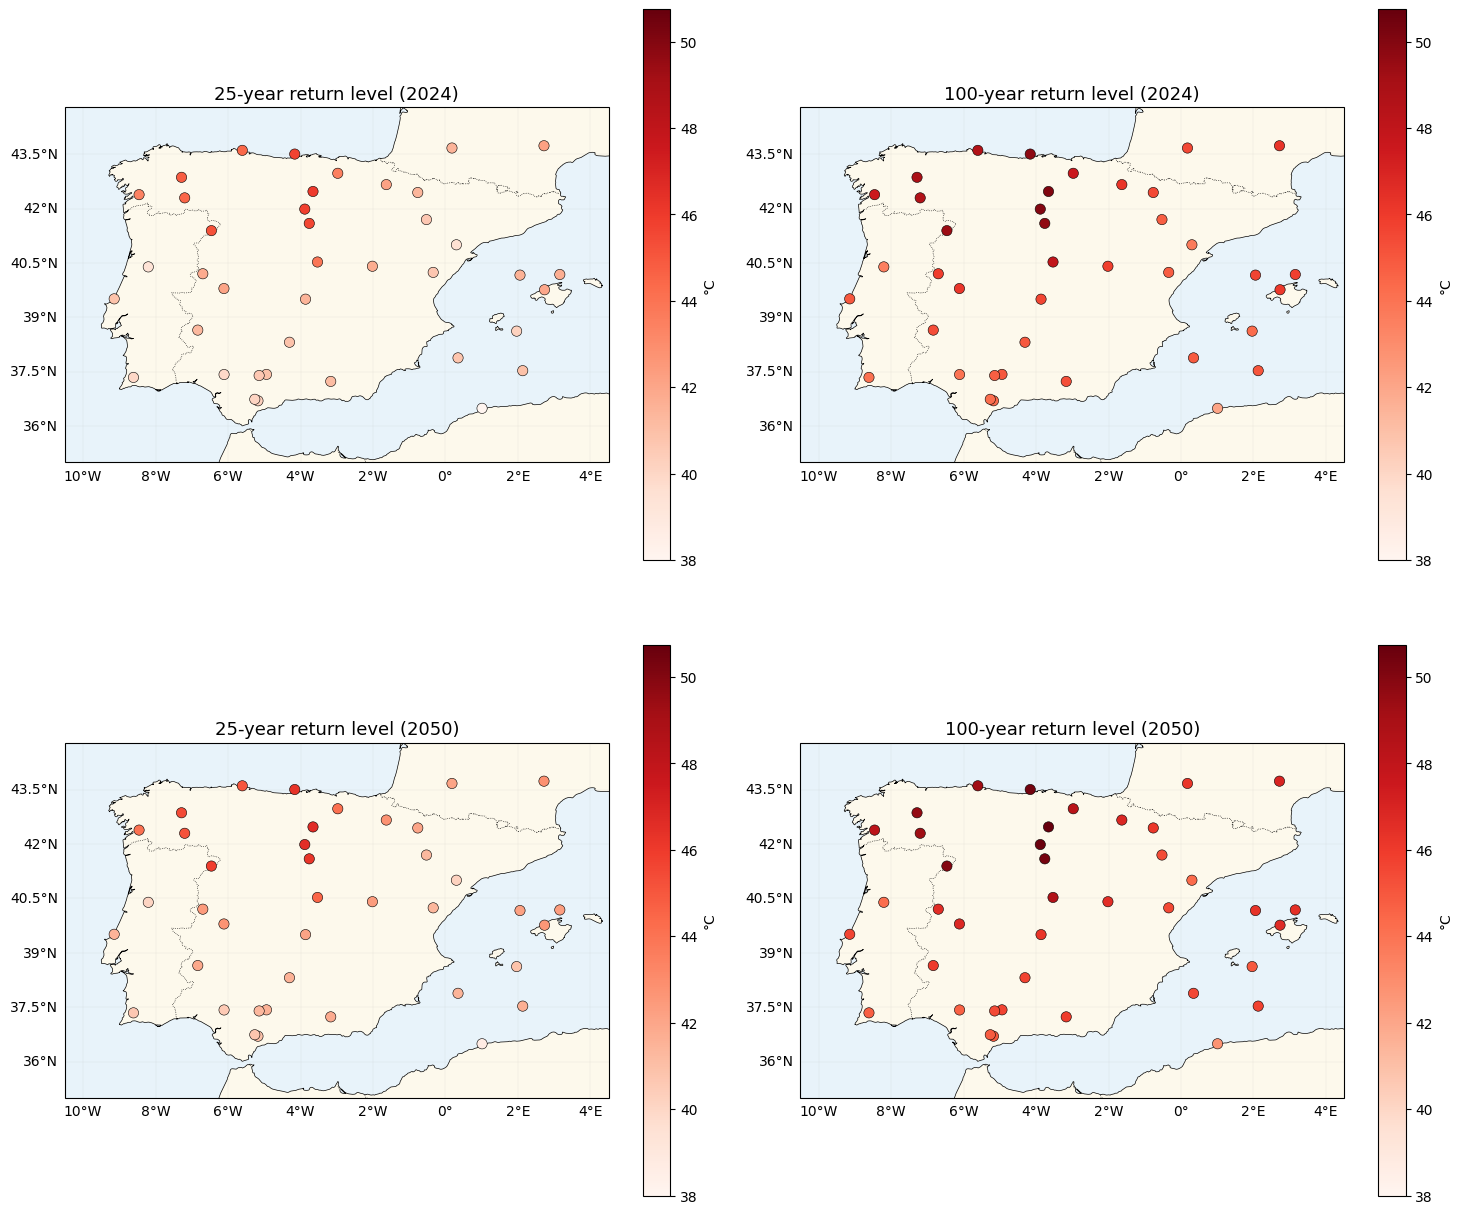

In [13]:
mu_field_mean = post["mu_field"].mean(0)  # (S,)
mu0_p = float(lat["mu0"].mean())
beta_p = float(lat["beta"].mean())
sigma_p = float(post["sigma"].mean())
xi_p = float(lat["xi"].mean())

gmst_2024 = gmst[-1]
gmst_2050 = gmst[-1] + (gmst[-1] - gmst[0]) / (T - 1) * (2050 - (YEAR_0 + T - 1))
print(f"GMST 2024 = {float(gmst_2024):.3f} °C, GMST 2050 (extrapolated) = {float(gmst_2050):.3f} °C")

loc_2024 = mu0_p + mu_field_mean + beta_p * (gmst_2024 - jnp.mean(gmst))
loc_2050 = mu0_p + mu_field_mean + beta_p * (gmst_2050 - jnp.mean(gmst))

z25_2024 = gev_return_level(25.0, loc_2024, sigma_p, xi_p)
z100_2024 = gev_return_level(100.0, loc_2024, sigma_p, xi_p)
z25_2050 = gev_return_level(25.0, loc_2050, sigma_p, xi_p)
z100_2050 = gev_return_level(100.0, loc_2050, sigma_p, xi_p)

stacked = jnp.stack([z25_2024, z100_2024, z25_2050, z100_2050])
vmin, vmax = float(jnp.min(stacked)), float(jnp.max(stacked))
print(f"2024 → 2050 mean shift in 100-yr return level: "
      f"{float(jnp.mean(z100_2050) - jnp.mean(z100_2024)):.2f} °C")

fig, axes = plt.subplots(2, 2, figsize=(15, 14), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, values, title in zip(
    axes.flat,
    [z25_2024, z100_2024, z25_2050, z100_2050],
    ["25-year return level (2024)", "100-year return level (2024)",
     "25-year return level (2050)", "100-year return level (2050)"],
    strict=True,
):
    plot_stations(ax, values, cmap="Reds", vlim=(vmin, vmax), label="°C")
    ax.set_title(title, fontsize=13)
plt.tight_layout()
plt.show()

## Summary

- **`pyrox.gp`** supplies the kernels (`Matern`, `RBF`, `matern_kernel`,
  `rbf_kernel`), the `GPPrior`, and whitened `gp_sample` latent fields.
- **`xtremax`** supplies the GEV likelihood
  (`GeneralizedExtremeValueDistribution`, machine-precision vs `scipy`) and the
  return-level helper (`gev_return_level`).
- **NumPyro SVI** with an `AutoNormal` guide replaces the hand-rolled
  variational scaffold; centering the latent fields fixes the additive
  identifiability so $\mu_0$ owns the level and $\beta$ owns the warming trend.

### Follow-ups

- **Multiplicative $K_s \otimes K_t$** — spatially-varying warming rates.
- **Non-stationary GEV** — let $\log\sigma$ and/or $\xi$ vary over space.
- **Real data** — swap the synthetic stations / maxima for AEMET or ERA5.